In [347]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [348]:
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('val_rmse','mean'),
                avg_mae=('val_mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse')
    topk_df = agg.groupby(['method'], group_keys=False).head(k)
    topk_d = topk_df[['method', 'avg_rmse', 'rmse', 'mae']]
    return topk_d, topk_df




In [349]:
def topk_per_d_per_method_lad(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('val_rmse','mean'),
                avg_mae=('val_mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_mae')
    topk_df = agg.groupby(['method'], group_keys=False).head(k)
    topk_d = topk_df[['method', 'avg_rmse', 'rmse', 'mae']]
    return topk_d, topk_df

In [350]:
data_ls_gaussian = pd.read_csv('../results/LSTransferTreeBoost_ablation_friedman.csv')
data = pd.read_csv('results/200_gaussian_6.csv')
data_ls_gaussian = data_ls_gaussian[(data_ls_gaussian['d'] == 6) & (data_ls_gaussian['target_instances'] == 200)]
data_ls_gaussian = data_ls_gaussian.drop(columns = ['target_instances', 'd'])
data_ls_gaussian

data = pd.concat([data, data_ls_gaussian])
data

data_slash = pd.read_csv('results/200_slash_6.csv')

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_9388\4162246015.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  LS_data['method'] = 'LS'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_9388\4162246015.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  LAD_data['method'] = 'LAD'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_9388\4162246015.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inste

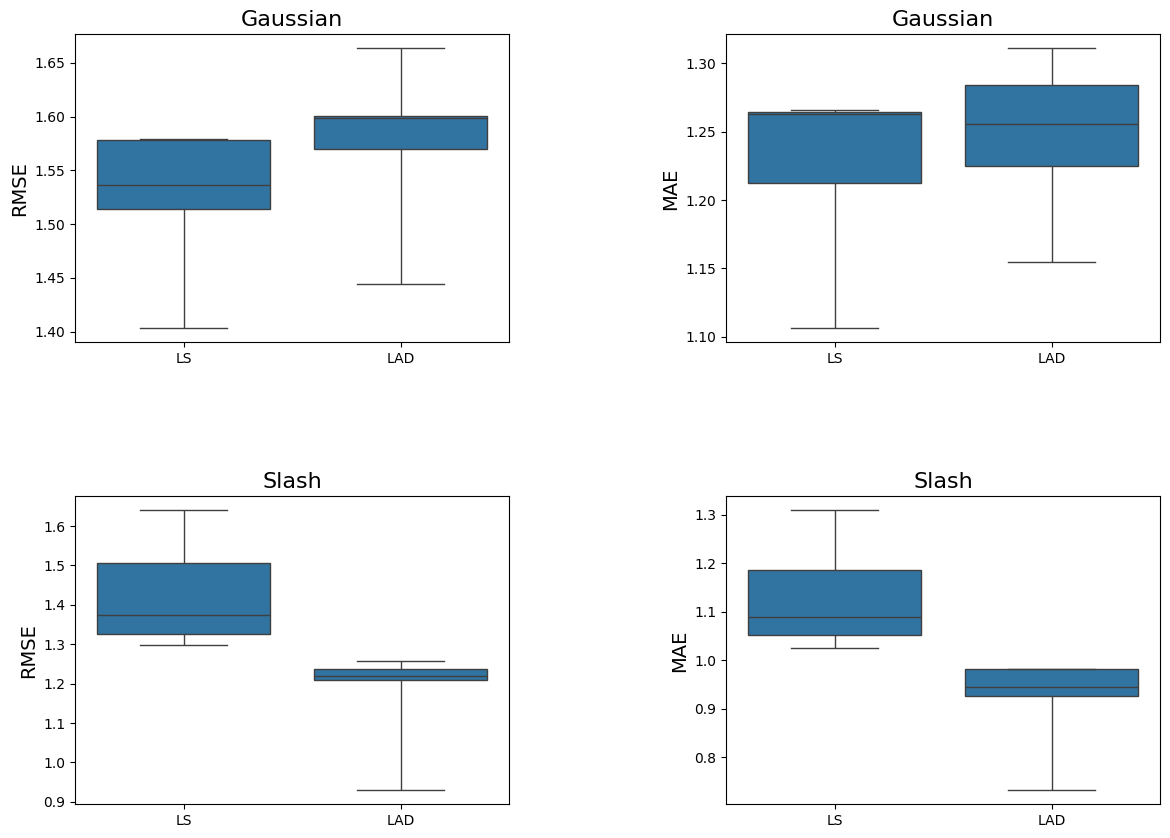

In [377]:
plt.figure(figsize = (14,10))


LS_data = data[data['method'] == 'LSTransferTreeBoost']
LAD_data = data[data['method'] == 'LADTransferTreeBoost']
LS_data['method'] = 'LS'
LAD_data['method'] = 'LAD'

best_LS, best_LS_params = topk_per_d_per_method(
    LS_data,
['v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=5
)

best_LAD, _ = topk_per_d_per_method(
    LAD_data,
['v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=5
)


df = pd.concat([best_LS, best_LAD])
plt.subplot(2,2,1)
sns.boxplot(data = df, x = 'method', y = 'rmse', whis = 10)
plt.gca().set_xlabel(None)
plt.gca().set_ylabel('RMSE', fontsize=14)
plt.gca().set_title('Gaussian', fontsize=16)


best_LS, best_LS_params = topk_per_d_per_method_lad(
    LS_data,
['v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=5
)

best_LAD, _ = topk_per_d_per_method_lad(
    LAD_data,
['v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=5
)


df = pd.concat([best_LS, best_LAD])
plt.subplot(2,2,2)
sns.boxplot(data = df, x = 'method', y = 'mae', whis = 10)
plt.gca().set_xlabel(None)
plt.gca().set_ylabel('MAE', fontsize=14)
plt.gca().set_title('Gaussian', fontsize=16)

LS_data = data_slash[data_slash['method'] == 'LSTransferTreeBoost']
LS_data['method'] = 'LS'
LAD_data = data_slash[data_slash['method'] == 'LADTransferTreeBoost']
LAD_data['method'] = 'LAD'

best_LS, best_LS_params = topk_per_d_per_method(
    LS_data,
['v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=5
)

best_LAD, _ = topk_per_d_per_method(
    LAD_data,
['v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=5
)


df = pd.concat([best_LS, best_LAD])
plt.subplot(2,2,3)
sns.boxplot(data = df, x = 'method', y = 'rmse', whis = 10)
plt.gca().set_xlabel(None)
plt.gca().set_ylabel('RMSE', fontsize=14)
plt.gca().set_title('Slash', fontsize=16)

best_LS, best_LS_params = topk_per_d_per_method_lad(
    LS_data,
['v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=5
)

best_LAD, _ = topk_per_d_per_method_lad(
    LAD_data,
['v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=5
)


df = pd.concat([best_LS, best_LAD])
plt.subplot(2,2,4)
sns.boxplot(data = df, x = 'method', y = 'mae', whis = 10)
plt.gca().set_xlabel(None)
plt.gca().set_ylabel('MAE', fontsize=14)
plt.gca().set_title('Slash', fontsize=16)
plt.subplots_adjust(wspace=0.5, hspace=0.5)
plt.savefig('vizes/ls-lad.png', dpi = 300, bbox_inches = 'tight', pad_inches = 0.1)
plt.show()






In [352]:
best_LS_params

,v,source_tree_size,target_tree_size,m_0,k,avg_rmse,avg_mae,n_seeds,Unnamed: 0,seed,method,val_rmse,val_mae,rmse,mae
31,0.1,2,2,0.9,0.05,1.419378,1.127815,5,62,2,LS,1.418758,1.129808,1.374877,1.089411
63,0.1,2,2,0.9,0.05,1.419378,1.127815,5,126,3,LS,1.278261,1.013541,1.296853,1.024847
127,0.1,2,2,0.9,0.05,1.419378,1.127815,5,254,5,LS,1.482905,1.158224,1.506367,1.186520
95,0.1,2,2,0.9,0.05,1.419378,1.127815,5,190,4,LS,1.636807,1.337881,1.639888,1.309220
159,0.1,2,2,0.9,0.05,1.419378,1.127815,5,318,6,LS,1.280161,0.999623,1.326739,1.050784


In [376]:
best_LAD

,method,avg_rmse,rmse,mae
28,LAD,1.161774,1.236566,0.981706
60,LAD,1.161774,0.929122,0.731219
124,LAD,1.161774,1.218661,0.945234
92,LAD,1.161774,1.256422,0.980641
156,LAD,1.161774,1.208560,0.926021
